In [ ]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import networkx as nx

In [ ]:
EDGES_CSV = "politician_edges.csv"
NODES_CSV = "politician_nodes.csv"

OUT_DIR = "sn_hw2_outputs_q1"
os.makedirs(OUT_DIR, exist_ok=True)

APPROX_K = None

CASE_DEGREE_RANK_MIN = 101
CASE_EIG_RANK_MAX = 50
CASE_COUNT = 3

plt.rcParams["figure.dpi"] = 140

In [ ]:
def save_df(df: pd.DataFrame, filename: str) -> str:
    path = os.path.join(OUT_DIR, filename)
    df.to_csv(path, index=False)
    return path

def rank_desc(values: pd.Series) -> pd.Series:
    # Rank in descending order (rank 1 = highest). Ties share the minimum rank.
    return values.rank(ascending=False, method="min").astype(int)

def load_data(edges_csv: str, nodes_csv: str) -> tuple[pd.DataFrame, pd.DataFrame]:
    edges = pd.read_csv(edges_csv)
    nodes = pd.read_csv(nodes_csv)

    if not {"id_1", "id_2"}.issubset(edges.columns):
        raise ValueError("politician_edges.csv must contain columns: id_1, id_2")
    if not {"id", "page_name"}.issubset(nodes.columns):
        raise ValueError("politician_nodes.csv must contain columns: id, page_name")

    edges = edges[["id_1", "id_2"]].copy()
    edges["id_1"] = edges["id_1"].astype(int)
    edges["id_2"] = edges["id_2"].astype(int)

    nodes = nodes.copy()
    nodes["id"] = nodes["id"].astype(int)

    return edges, nodes

def build_graph(edges: pd.DataFrame, nodes: pd.DataFrame) -> nx.Graph:
    # Undirected graph (mutual likes)
    G = nx.from_pandas_edgelist(edges, source="id_1", target="id_2", create_using=nx.Graph)
    # Ensure isolates (if any) are included
    G.add_nodes_from(nodes["id"].tolist())
    return G

def attach_names(df: pd.DataFrame, nodes: pd.DataFrame) -> pd.DataFrame:
    keep_cols = [c for c in ["id", "page_name", "page_type"] if c in nodes.columns]
    return df.merge(nodes[keep_cols], on="id", how="left")

def fit_line_and_residuals(x: np.ndarray, y: np.ndarray, use_log1p: bool = True) -> tuple[np.ndarray, float, float]:
    # Fit y = a*x + b on optionally log-transformed inputs
    x_fit = np.log1p(x) if use_log1p else x
    y_fit = np.log1p(y) if use_log1p else y
    a, b = np.polyfit(x_fit, y_fit, deg=1)
    y_hat = a * x_fit + b
    resid = y_fit - y_hat
    return resid, a, b


edges_df, nodes_df = load_data(EDGES_CSV, NODES_CSV)
G = build_graph(edges_df, nodes_df)

n_nodes = G.number_of_nodes()
n_edges = G.number_of_edges()

print(f"Graph: {n_nodes} nodes, {n_edges} edges")
cc_sizes = sorted([len(c) for c in nx.connected_components(G)], reverse=True)
print(f"Connected components: {len(cc_sizes)} | Largest CC size: {cc_sizes[0]}")

Graph: 5696 nodes, 36836 edges
Connected components: 1 | Largest CC size: 5696



(a-1) Top-10 Normalized Degree


,id,page_name,deg_norm,degree,rank_deg_norm
97,14650,Manfred Weber,0.056716,323,1
809,20415,Joachim Herrmann,0.044425,253,2
786,21491,Katarina Barley,0.038982,222,3
788,3070,Arno Klare MdB,0.038455,219,4
791,7357,Katja Mast,0.037928,216,5
389,11003,Barack Obama,0.034416,196,6
547,18155,Angela Merkel,0.032485,185,7
427,18819,Niels Annen,0.031080,177,8
438,17056,Martin Schulz,0.030553,174,9
150,16809,Sir Peter Bottomley MP,0.030202,172,10



(a-1) Top-10 Eigenvector


,id,page_name,eigenvector,degree,rank_eigenvector
786,21491,Katarina Barley,0.183731,222,1
788,3070,Arno Klare MdB,0.180991,219,2
791,7357,Katja Mast,0.177871,216,3
782,16427,Christian Petry,0.167318,164,4
790,9363,Heike Baehrens,0.166723,166,5
775,22100,Klaus Mindrup,0.155757,143,6
827,8893,Michelle Müntefering,0.149876,129,7
427,18819,Niels Annen,0.146286,177,8
792,22110,Johannes Schraps,0.143444,140,9
1200,8351,Sigmar Gabriel,0.142743,134,10



(a-1) Top-10 Closeness


,id,page_name,closeness,degree,rank_closeness
389,11003,Barack Obama,0.352217,196,1
437,3906,Michael Roth,0.309343,117,2
427,18819,Niels Annen,0.307406,177,3
1821,19877,Tanja Fajon,0.302042,45,4
55,14862,Malcolm Turnbull,0.299642,113,5
1215,6357,Mariano Rajoy Brey,0.299280,64,6
443,11719,Achim Post,0.298997,126,7
894,11149,Peter Tauber,0.296800,108,8
780,9554,Dietmar Nietan,0.293905,133,9
398,5448,Hillary Clinton,0.293829,61,10


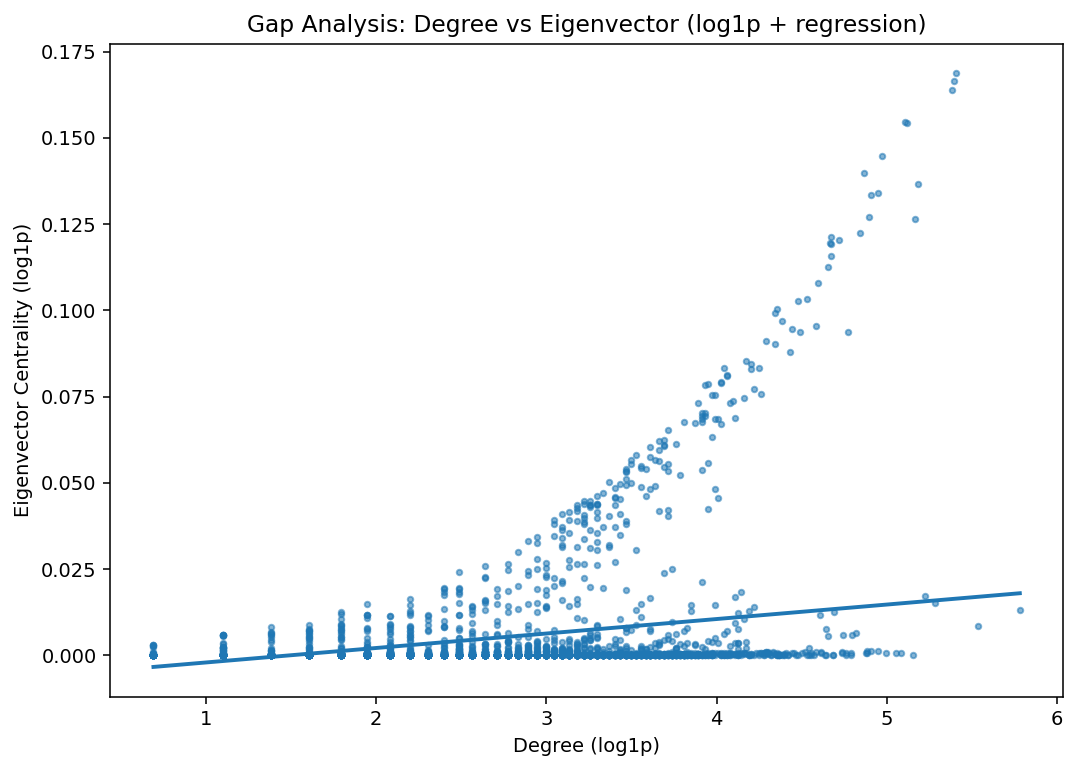

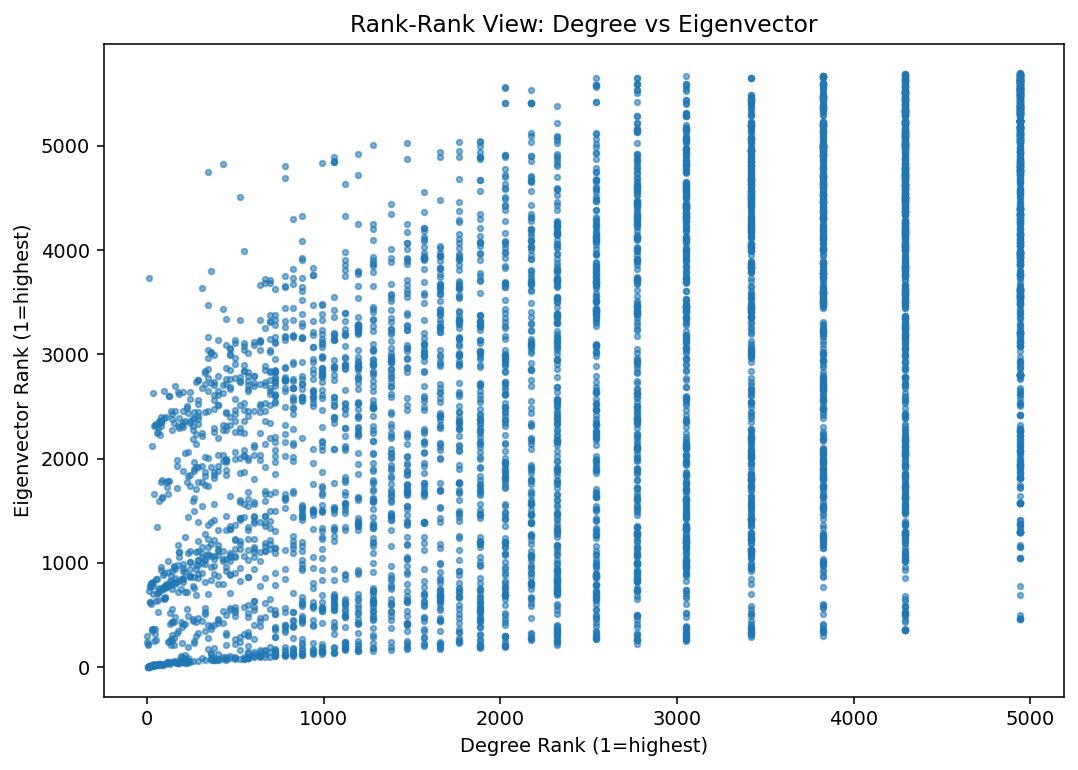


(a-3) Selected 3 case-study politicians (Low degree, High eigenvector):


,id,page_name,degree,deg_norm,eigenvector,closeness,rank_degree,rank_eigenvector,rank_closeness
1241,17495,Andrea Nahles,72,0.012643,0.095334,0.250947,102,30,320
777,7860,Barbara Hendricks,64,0.011238,0.089077,0.252875,129,33,283
1196,15475,Bärbel Kofler,66,0.011589,0.088132,0.251058,120,34,317


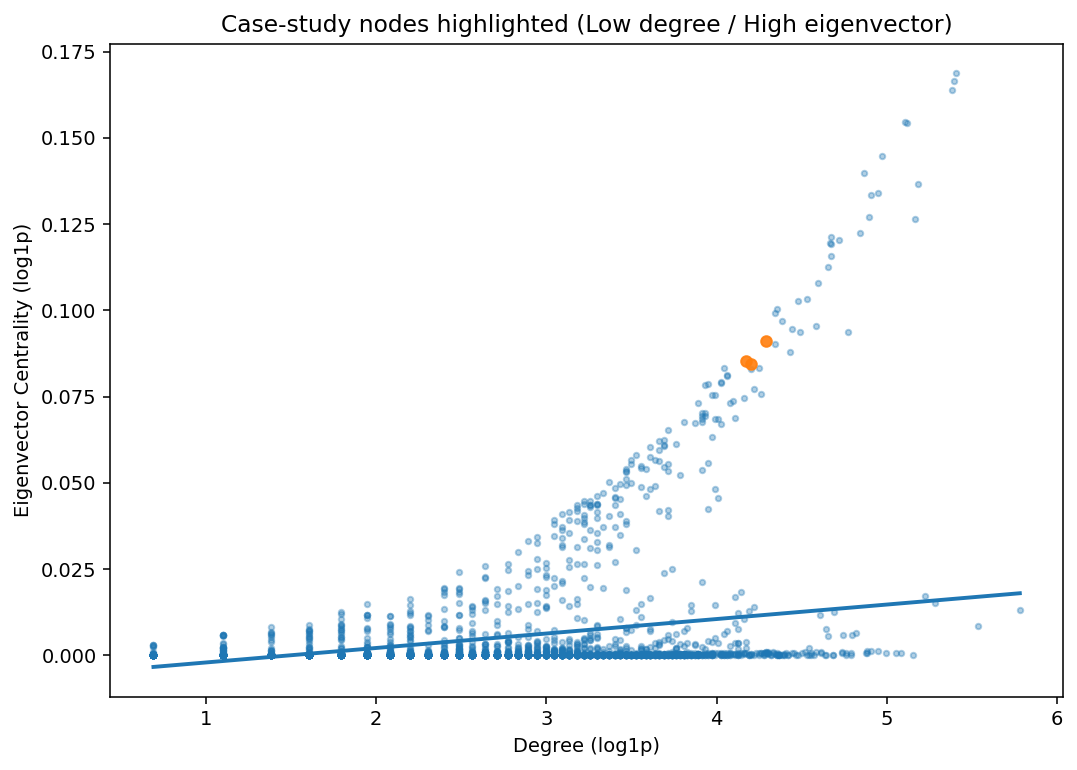

In [ ]:
deg = dict(G.degree())
deg_norm = {k: v / (n_nodes - 1) for k, v in deg.items()}

eig = nx.eigenvector_centrality(G, max_iter=2000, tol=1e-6)
clo = nx.closeness_centrality(G)

metrics = pd.DataFrame({
    "id": list(G.nodes()),
    "degree": pd.Series(deg),
    "deg_norm": pd.Series(deg_norm),
    "eigenvector": pd.Series(eig),
    "closeness": pd.Series(clo),
}).fillna(0.0)

metrics["rank_degree"] = rank_desc(metrics["degree"])
metrics["rank_deg_norm"] = rank_desc(metrics["deg_norm"])
metrics["rank_eigenvector"] = rank_desc(metrics["eigenvector"])
metrics["rank_closeness"] = rank_desc(metrics["closeness"])

metrics = attach_names(metrics, nodes_df)

top10_deg = metrics.sort_values("rank_deg_norm").head(10)[
    ["id", "page_name", "deg_norm", "degree", "rank_deg_norm"]
]
top10_eig = metrics.sort_values("rank_eigenvector").head(10)[
    ["id", "page_name", "eigenvector", "degree", "rank_eigenvector"]
]
top10_clo = metrics.sort_values("rank_closeness").head(10)[
    ["id", "page_name", "closeness", "degree", "rank_closeness"]
]

save_df(top10_deg, "a_top10_deg_norm.csv")
save_df(top10_eig, "a_top10_eigenvector.csv")
save_df(top10_clo, "a_top10_closeness.csv")

print("\n(a-1) Top-10 Normalized Degree"); display(top10_deg)
print("\n(a-1) Top-10 Eigenvector"); display(top10_eig)
print("\n(a-1) Top-10 Closeness"); display(top10_clo)

x = metrics["degree"].to_numpy(dtype=float)
y = metrics["eigenvector"].to_numpy(dtype=float)

resid, a, b = fit_line_and_residuals(x, y, use_log1p=True)
metrics["eig_gap_resid_logfit"] = resid

plt.figure(figsize=(7.8, 5.6))
plt.scatter(np.log1p(x), np.log1p(y), s=8, alpha=0.55)
xs = np.linspace(np.log1p(x).min(), np.log1p(x).max(), 200)
plt.plot(xs, a * xs + b, linewidth=2)
plt.xlabel("Degree (log1p)")
plt.ylabel("Eigenvector Centrality (log1p)")
plt.title("Gap Analysis: Degree vs Eigenvector (log1p + regression)")
plt.tight_layout()
plt.show()
plt.figure(figsize=(7.8, 5.6))
plt.scatter(metrics["rank_degree"], metrics["rank_eigenvector"], s=8, alpha=0.55)
plt.xlabel("Degree Rank (1=highest)")
plt.ylabel("Eigenvector Rank (1=highest)")
plt.title("Rank-Rank View: Degree vs Eigenvector")
plt.tight_layout()
plt.show()

case_pool = metrics[
    (metrics["rank_degree"] >= CASE_DEGREE_RANK_MIN) &
    (metrics["rank_eigenvector"] <= CASE_EIG_RANK_MAX)
].copy()

case_pool = case_pool.sort_values(["rank_eigenvector", "rank_degree", "eig_gap_resid_logfit"], ascending=[True, True, False])

case3 = case_pool.head(CASE_COUNT)[
    ["id", "page_name", "degree", "deg_norm", "eigenvector", "closeness",
     "rank_degree", "rank_eigenvector", "rank_closeness"]
]
save_df(case3, "a_case_study_3nodes.csv")

print("\n(a-3) Selected 3 case-study politicians (Low degree, High eigenvector):")
display(case3)

chosen_ids = set(case3["id"].astype(int).tolist())
mask = metrics["id"].astype(int).isin(chosen_ids)

plt.figure(figsize=(7.8, 5.6))
plt.scatter(np.log1p(x[~mask.to_numpy()]), np.log1p(y[~mask.to_numpy()]), s=8, alpha=0.35)
plt.scatter(np.log1p(x[mask.to_numpy()]), np.log1p(y[mask.to_numpy()]), s=30, alpha=0.9)
plt.plot(xs, a * xs + b, linewidth=2)
plt.xlabel("Degree (log1p)")
plt.ylabel("Eigenvector Centrality (log1p)")
plt.title("Case-study nodes highlighted (Low degree / High eigenvector)")
plt.tight_layout()
plt.show()



(b-1) Top-10 Betweenness (with Degree Rank):


,id,page_name,betweenness,rank_betweenness,degree,rank_degree
389,11003,Barack Obama,0.416556,1,196,6
398,5448,Hillary Clinton,0.067820,2,61,141
547,18155,Angela Merkel,0.060257,3,185,7
118,11611,Justin Trudeau,0.060161,4,123,27
55,14862,Malcolm Turnbull,0.056797,5,113,35
97,14650,Manfred Weber,0.054810,6,323,1
894,11149,Peter Tauber,0.047660,7,108,38
111,365,Betinho Gomes,0.045638,8,66,120
427,18819,Niels Annen,0.043659,9,177,8
345,4300,Boris Johnson,0.037503,10,28,665


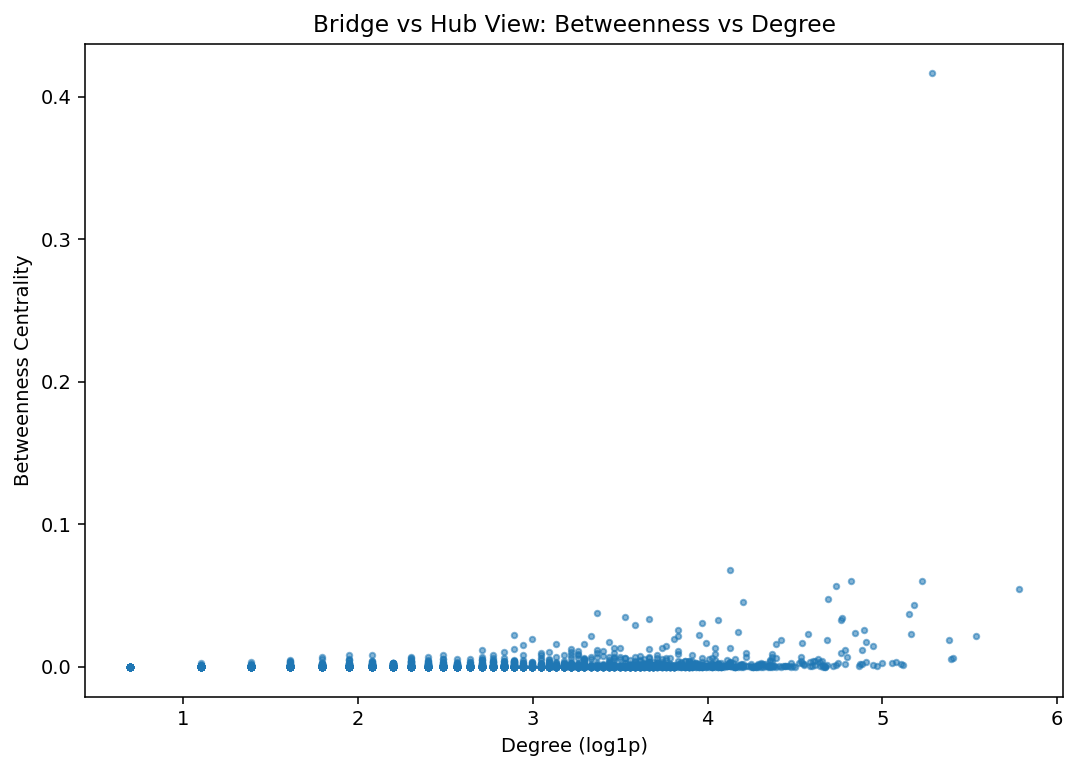


Saved CSVs (report-needed only) in: sn_hw2_outputs_q1
- a_top10_deg_norm.csv
- a_top10_eigenvector.csv
- a_top10_closeness.csv
- a_case_study_3nodes.csv
- b_top10_betweenness_with_degree_rank.csv


In [ ]:
if APPROX_K is None:
    btw = nx.betweenness_centrality(G, normalized=True)
else:
    rng = np.random.default_rng(42)
    sample_nodes = rng.choice(list(G.nodes()), size=min(APPROX_K, n_nodes), replace=False).tolist()
    btw = nx.betweenness_centrality_subset(G, sources=sample_nodes, targets=sample_nodes, normalized=True)

metrics["betweenness"] = metrics["id"].map(btw).fillna(0.0)
metrics["rank_betweenness"] = rank_desc(metrics["betweenness"])

top10_btw = metrics.sort_values("rank_betweenness").head(10)[
    ["id", "page_name", "betweenness", "rank_betweenness", "degree", "rank_degree"]
]
save_df(top10_btw, "b_top10_betweenness_with_degree_rank.csv")

print("\n(b-1) Top-10 Betweenness (with Degree Rank):")
display(top10_btw)

x3 = metrics["degree"].to_numpy(dtype=float)
y3 = metrics["betweenness"].to_numpy(dtype=float)

plt.figure(figsize=(7.8, 5.6))
plt.scatter(np.log1p(x3), y3, s=8, alpha=0.55)
plt.xlabel("Degree (log1p)")
plt.ylabel("Betweenness Centrality")
plt.title("Bridge vs Hub View: Betweenness vs Degree")
plt.tight_layout()
plt.show()

print("\nSaved CSVs (report-needed only) in:", OUT_DIR)
print("- a_top10_deg_norm.csv")
print("- a_top10_eigenvector.csv")
print("- a_top10_closeness.csv")
print("- a_case_study_3nodes.csv")
print("- b_top10_betweenness_with_degree_rank.csv")